In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold,cross_val_score
from sklearn.metrics import make_scorer,mean_squared_error

In [4]:
df=pd.read_csv("SolarPrediction.csv")

In [13]:
df=df.select_dtypes(include=[np.number])

In [14]:
df.head()

,UNIXTime,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
0,1475229326,1.21,48,30.46,59,177.39,5.62
1,1475229023,1.21,48,30.46,58,176.78,3.37
2,1475228726,1.23,48,30.46,57,158.75,3.37
3,1475228421,1.21,48,30.46,60,137.71,3.37
4,1475228124,1.17,48,30.46,62,104.95,5.62


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32686 entries, 0 to 32685
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UNIXTime                32686 non-null  int64  
 1   Radiation               32686 non-null  float64
 2   Temperature             32686 non-null  int64  
 3   Pressure                32686 non-null  float64
 4   Humidity                32686 non-null  int64  
 5   WindDirection(Degrees)  32686 non-null  float64
 6   Speed                   32686 non-null  float64
dtypes: float64(4), int64(3)
memory usage: 1.7 MB


In [16]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [17]:
model=LinearRegression()

In [18]:
kfold=KFold(n_splits=5,shuffle=True,random_state=42)

In [19]:
r2_scores = cross_val_score(model, X, y, cv=kfold, scoring="r2")

In [20]:
mse_scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring=make_scorer(mean_squared_error)
)

In [21]:
print("R² Scores:", r2_scores)
print("Average R²:", np.mean(r2_scores))

print("MSE Scores:", mse_scores)
print("Average MSE:", np.mean(mse_scores))

R² Scores: [0.08907426 0.08915364 0.09909108 0.08901196 0.07247218]
Average R²: 0.0877606232475382
MSE Scores: [11.25805563 11.57361332 10.98595575 10.67539752 11.06757379]
Average MSE: 11.11211920418875


# VIZUALIZATION

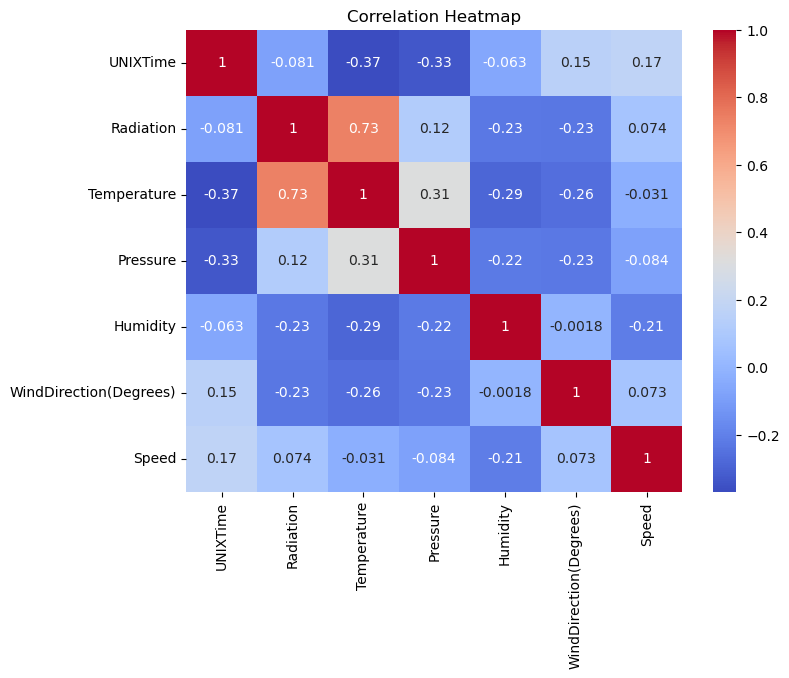

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()